# 20 — Cross-Dataset Overlap Analysis

## Purpose

This notebook evaluates the structural overlap between the active Cycle 1 datasets of the project.

The current operational cycle is restricted to DepMap/CCLE molecular resources and GDSC pharmacogenomic response data. The goal is to determine how well these datasets can be connected through shared cell-line identifiers before proceeding to formal harmonization.

This notebook focuses on:

- overlap between DepMap models and GDSC cell lines;
- availability and completeness of shared identifiers;
- lineage coverage within overlapping and non-overlapping subsets;
- consistency between DepMap metadata, omics profiles, expression data, mutation data, and GDSC response records;
- identification of integration bottlenecks before constructing harmonized analysis tables.

## Inputs

Expected active inputs:

- `data/raw/depmap/Model.csv`
- `data/raw/depmap/OmicsProfiles.csv`
- `data/raw/depmap/OmicsExpressionProteinCodingGenesTPMLogp1.csv`
- `data/raw/depmap/OmicsSomaticMutations.csv`
- `data/raw/gdsc/GDSC2_fitted_dose_response_27Oct23.xlsx`

## Outputs

Expected outputs:

- DepMap–GDSC overlap summaries;
- shared and non-shared cell-line tables;
- identifier completeness summaries;
- lineage-level overlap summaries;
- integration-readiness notes for Phase 3.

## Upstream dependency

This notebook depends on the Phase 1 dataset inventory:

- `notebooks/phase1_download/10_dataset_inventory.ipynb`

The Phase 1 notebook establishes file availability, basic schema inspection, and raw dataset structure. This notebook uses those active datasets to evaluate cross-dataset interoperability.

## Downstream consumers

The outputs of this notebook will inform:

- `21_identifier_landscape_and_lineage_coverage.ipynb`
- `22_modality_readiness_matrix.ipynb`
- `30_cell_line_identifier_harmonization.ipynb`

## Scope lock

Active Cycle 1 scope:

- DepMap/CCLE metadata;
- DepMap transcriptomic profiles;
- DepMap somatic mutation metadata;
- GDSC drug-response data.

Deferred datasets and modalities:

- CRISPR/RNAi dependency screens;
- PRISM;
- CTRP;
- LINCS/CMap;
- TCGA/GDC;
- DNA methylation;
- clinical outcome modeling.

## Imports and configuration

This section loads the core libraries and defines the project paths used throughout the notebook.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.paths import Paths

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 160)

PROJECT_ROOT = Paths.root
DEPMAP_DIR = Paths.depmap
GDSC_DIR = Paths.gdsc
REPORTS_DIR = PROJECT_ROOT / "reports" / "phase2_eda"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")


PROJECT_ROOT: c:\Users\paula\OneDrive\Documentos\Proyectos\pancancer-epigenetics


## Dataset loading

This section loads the active Cycle 1 datasets used for overlap and interoperability analysis.

Only datasets included in the current operational scope are loaded.

In [2]:
# -------------------------------------------------------------------
# DepMap / CCLE
# -------------------------------------------------------------------

depmap_model_path = (
    DEPMAP_DIR
    / "Model.csv"
)

depmap_omics_profiles_path = (
    DEPMAP_DIR
    / "OmicsProfiles.csv"
)

depmap_expression_path = (
    DEPMAP_DIR
    / "OmicsExpressionProteinCodingGenesTPMLogp1.csv"
)

depmap_mutation_path = (
    DEPMAP_DIR
    / "OmicsSomaticMutations.csv"
)

# -------------------------------------------------------------------
# GDSC
# -------------------------------------------------------------------

gdsc_response_path = (
    GDSC_DIR
    / "GDSC2_fitted_dose_response_27Oct23.xlsx"
)


## File existence check

Before loading the datasets, verify that all expected files are available locally.

In [3]:
required_files = {
    "depmap_model": depmap_model_path,
    "depmap_omics_profiles": depmap_omics_profiles_path,
    "depmap_expression": depmap_expression_path,
    "depmap_mutations": depmap_mutation_path,
    "gdsc_response": gdsc_response_path,
}

file_status = pd.DataFrame({
    "dataset": required_files.keys(),
    "path": [str(path.relative_to(PROJECT_ROOT)) for path in required_files.values()],
    "exists": [path.exists() for path in required_files.values()],
})

file_status

,dataset,path,exists
0,depmap_model,data\raw\depmap\Model.csv,True
1,depmap_omics_profiles,data\raw\depmap\OmicsProfiles.csv,True
2,depmap_expression,data\raw\depmap\OmicsExpressionProteinCodingGe...,True
3,depmap_mutations,data\raw\depmap\OmicsSomaticMutations.csv,True
4,gdsc_response,data\raw\gdsc\GDSC2_fitted_dose_response_27Oct...,True


## Load datasets

Large matrices are loaded only to the extent required for overlap and identifier analysis.

In [4]:
# -------------------------------------------------------------------
# DepMap metadata
# -------------------------------------------------------------------

depmap_models = pd.read_csv(
    depmap_model_path,
    low_memory=False
)

depmap_omics_profiles = pd.read_csv(
    depmap_omics_profiles_path,
    low_memory=False
)

# -------------------------------------------------------------------
# Expression matrix
# Only metadata-level inspection is needed at this stage
# -------------------------------------------------------------------

depmap_expression = pd.read_csv(
    depmap_expression_path,
    nrows=5,
    low_memory=False
)

# -------------------------------------------------------------------
# Mutation table
# Only metadata-level inspection is needed at this stage
# -------------------------------------------------------------------

depmap_mutations = pd.read_csv(
    depmap_mutation_path,
    nrows=1000,
    low_memory=False
)

# -------------------------------------------------------------------
# GDSC response
# -------------------------------------------------------------------

gdsc_response = pd.read_excel(
    gdsc_response_path
)

## Dataset overview

Basic dimensional inspection of the loaded datasets.

In [5]:
loaded_datasets = {
    "depmap_models": depmap_models,
    "depmap_omics_profiles": depmap_omics_profiles,
    "depmap_expression_preview": depmap_expression,
    "depmap_mutations_preview": depmap_mutations,
    "gdsc_response": gdsc_response,
}

dataset_overview = pd.DataFrame({
    "dataset": loaded_datasets.keys(),
    "rows": [df.shape[0] for df in loaded_datasets.values()],
    "columns": [df.shape[1] for df in loaded_datasets.values()],
})

dataset_overview

,dataset,rows,columns
0,depmap_models,2105,47
1,depmap_omics_profiles,4518,9
2,depmap_expression_preview,5,19194
3,depmap_mutations_preview,1000,70
4,gdsc_response,242036,16


## Column inspection

Inspect the identifier landscape before computing overlaps.

In [6]:
for dataset_name, df in loaded_datasets.items():

    print("\n" + "=" * 80)
    print(dataset_name)
    print("=" * 80)

    print(list(df.columns[:100]))


depmap_models
['ModelID', 'PatientID', 'CellLineName', 'StrippedCellLineName', 'DepmapModelType', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype', 'OncotreeCode', 'PatientSubtypeFeatures', 'RRID', 'Age', 'AgeCategory', 'Sex', 'PatientRace', 'PrimaryOrMetastasis', 'SampleCollectionSite', 'SourceType', 'SourceDetail', 'CatalogNumber', 'ModelType', 'TissueOrigin', 'ModelDerivationMaterial', 'ModelTreatment', 'PatientTreatmentStatus', 'PatientTreatmentType', 'PatientTreatmentDetails', 'Stage', 'StagingSystem', 'PatientTumorGrade', 'PatientTreatmentResponse', 'GrowthPattern', 'OnboardedMedia', 'FormulationID', 'SerumFreeMedia', 'PlateCoating', 'EngineeredModel', 'EngineeredModelDetails', 'CulturedResistanceDrug', 'PublicComments', 'CCLEName', 'HCMIID', 'ModelAvailableInDbgap', 'ModelSubtypeFeatures', 'WTSIMasterCellID', 'SangerModelID', 'COSMICID']

depmap_omics_profiles
['ProfileID', 'ModelCondition', 'ModelID', 'Datatype', 'WESKit', 'Product', 'Stranded', 'Source', 'Shared

---

## Identifier landscape overview

Before computing dataset overlap, it is necessary to identify which identifier systems are available across DepMap and GDSC.

In [7]:
identifier_related_columns = {
    "depmap_models": [
        col for col in depmap_models.columns
        if any(
            keyword in col.lower()
            for keyword in [
                "id",
                "name",
                "lineage",
                "tissue",
                "model",
                "ccle",
                "sanger"
            ]
        )
    ],

    "gdsc_response": [
        col for col in gdsc_response.columns
        if any(
            keyword in col.lower()
            for keyword in [
                "id",
                "name",
                "line",
                "tissue",
                "model",
                "sanger"
            ]
        )
    ]
}

identifier_related_columns

{'depmap_models': ['ModelID',
  'PatientID',
  'CellLineName',
  'StrippedCellLineName',
  'DepmapModelType',
  'OncotreeLineage',
  'RRID',
  'ModelType',
  'TissueOrigin',
  'ModelDerivationMaterial',
  'ModelTreatment',
  'FormulationID',
  'EngineeredModel',
  'EngineeredModelDetails',
  'CCLEName',
  'HCMIID',
  'ModelAvailableInDbgap',
  'ModelSubtypeFeatures',
  'WTSIMasterCellID',
  'SangerModelID',
  'COSMICID'],
 'gdsc_response': ['NLME_RESULT_ID',
  'NLME_CURVE_ID',
  'CELL_LINE_NAME',
  'SANGER_MODEL_ID',
  'DRUG_ID',
  'DRUG_NAME',
  'PATHWAY_NAME']}

## DepMap metadata overview

Inspect the primary metadata structure available in the DepMap model table.

In [8]:
depmap_models.head()

,ModelID,PatientID,CellLineName,StrippedCellLineName,DepmapModelType,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,OncotreeCode,PatientSubtypeFeatures,RRID,Age,AgeCategory,Sex,PatientRace,PrimaryOrMetastasis,SampleCollectionSite,SourceType,SourceDetail,CatalogNumber,ModelType,TissueOrigin,ModelDerivationMaterial,ModelTreatment,PatientTreatmentStatus,PatientTreatmentType,PatientTreatmentDetails,Stage,StagingSystem,PatientTumorGrade,PatientTreatmentResponse,GrowthPattern,OnboardedMedia,FormulationID,SerumFreeMedia,PlateCoating,EngineeredModel,EngineeredModelDetails,CulturedResistanceDrug,PublicComments,CCLEName,HCMIID,ModelAvailableInDbgap,ModelSubtypeFeatures,WTSIMasterCellID,SangerModelID,COSMICID
0,ACH-000001,PT-gj46wT,NIH:OVCAR-3,NIHOVCAR3,HGSOC,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,HGSOC,NaN,CVCL_0465,60.0,Adult,Female,caucasian,Metastatic,ascites,ATCC,ATCC,HTB-71,Cell Line,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adherent,MF-001-041,RPMI + 20% FBS + 0.01 mg/ml insulin,False,NaN,NaN,NaN,NaN,NaN,NIHOVCAR3_OVARY,NaN,Available in SRA,NaN,2201.0,SIDM00105,905933.0
1,ACH-000002,PT-5qa3uk,HL-60,HL60,AML,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,AML,"TP53(del), CDKN2A and NRAS mutations [PubMed=2...",CVCL_0002,36.0,Adult,Female,caucasian,Primary,haematopoietic_and_lymphoid_tissue,ATCC,ATCC,CCL-240,Cell Line,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Suspension,MF-005-001,IMDM + 10% FBS,False,NaN,NaN,NaN,NaN,NaN,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,Available in SRA,NaN,55.0,SIDM00829,905938.0
2,ACH-000003,PT-puKIyc,CACO2,CACO2,COAD,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,COAD,NaN,CVCL_0025,72.0,Adult,Male,caucasian,Primary,Colon,ATCC,ATCC,HTB-37,Cell Line,NaN,NaN,NaN,Unknown,NaN,NaN,NaN,NaN,NaN,NaN,Adherent,MF-015-009,EMEM + 20% FBS,False,NaN,NaN,NaN,NaN,NaN,CACO2_LARGE_INTESTINE,NaN,Available in SRA,NaN,NaN,SIDM00891,NaN
3,ACH-000004,PT-q4K2cp,HEL,HEL,AML,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,AML,"JAK2 and TP53 mutations,",CVCL_0001,30.0,Adult,Male,caucasian,Primary,haematopoietic_and_lymphoid_tissue,DSMZ,DSMZ,ACC 11,Cell Line,NaN,NaN,NaN,Post-treatment,NaN,NaN,NaN,NaN,NaN,NaN,Suspension,MF-001-001,RPMI + 10% FBS,False,NaN,NaN,NaN,NaN,NaN,HEL_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,Available in SRA,NaN,783.0,SIDM00594,907053.0
4,ACH-000005,PT-q4K2cp,HEL 92.1.7,HEL9217,AML,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,AML,JAK2 and TP53 mutations,CVCL_2481,30.0,Adult,Male,caucasian,NaN,bone_marrow,ATCC,ATCC,HEL9217,Cell Line,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Mixed,MF-001-001,RPMI + 10% FBS,False,NaN,NaN,NaN,NaN,NaN,HEL9217_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,NaN,Available in SRA,NaN,NaN,SIDM00593,NaN


## Primary overlap identifiers

DepMap and GDSC share a direct cell-line identifier through the Sanger model ID system.

For this notebook, the primary cross-dataset bridge is:

- DepMap: `SangerModelID`
- GDSC: `SANGER_MODEL_ID`

COSMIC identifiers are retained as secondary consistency checks because they may be less complete or less stable across releases.

In [9]:
DEP_MAP_ID_COL = "ModelID"
DEPMAP_SANGER_COL = "SangerModelID"
DEPMAP_COSMIC_COL = "COSMICID"
DEPMAP_CELL_LINE_COL = "CellLineName"
DEPMAP_LINEAGE_COL = "OncotreeLineage"

GDSC_SANGER_COL = "SANGER_MODEL_ID"
GDSC_COSMIC_COL = "COSMIC_ID"
GDSC_CELL_LINE_COL = "CELL_LINE_NAME"
GDSC_DRUG_COL = "DRUG_NAME"
GDSC_DRUG_ID_COL = "DRUG_ID"
GDSC_LN_IC50_COL = "LN_IC50"
GDSC_AUC_COL = "AUC"

## Identifier completeness

This section evaluates the completeness of the primary and secondary identifiers required for DepMap–GDSC overlap analysis.

In [ ]:
identifier_completeness = pd.DataFrame([
    {
        "dataset": "DepMap",
        "column": DEPMAP_SANGER_COL,
        "rows": len(depmap_models),
        "missing": depmap_models[DEPMAP_SANGER_COL].isna().sum(),
        "missing_pct": depmap_models[DEPMAP_SANGER_COL].isna().mean() * 100,
        "unique_non_missing": depmap_models[DEPMAP_SANGER_COL].nunique(dropna=True),
    },
    {
        "dataset": "DepMap",
        "column": DEPMAP_COSMIC_COL,
        "rows": len(depmap_models),
        "missing": depmap_models[DEPMAP_COSMIC_COL].isna().sum(),
        "missing_pct": depmap_models[DEPMAP_COSMIC_COL].isna().mean() * 100,
        "unique_non_missing": depmap_models[DEPMAP_COSMIC_COL].nunique(dropna=True),
    },
    {
        "dataset": "GDSC",
        "column": GDSC_SANGER_COL,
        "rows": len(gdsc_response),
        "missing": gdsc_response[GDSC_SANGER_COL].isna().sum(),
        "missing_pct": gdsc_response[GDSC_SANGER_COL].isna().mean() * 100,
        "unique_non_missing": gdsc_response[GDSC_SANGER_COL].nunique(dropna=True),
    },
#    {
#        "dataset": "GDSC",
#        "column": GDSC_COSMIC_COL,
#        "rows": len(gdsc_response),
#        "missing": gdsc_response[GDSC_COSMIC_COL].isna().sum(),
#        "missing_pct": gdsc_response[GDSC_COSMIC_COL].isna().mean() * 100,
#        "unique_non_missing": gdsc_response[GDSC_COSMIC_COL].nunique(dropna=True),
#     },
])

identifier_completeness

,dataset,column,rows,missing,missing_pct,unique_non_missing
0,DepMap,SangerModelID,2105,887,42.137767,1217
1,DepMap,COSMICID,2105,1128,53.586698,977
2,GDSC,SANGER_MODEL_ID,242036,0,0.000000,969


## DepMap–GDSC cell-line overlap

This section quantifies the overlap between DepMap and GDSC using Sanger model identifiers as the primary bridge.

In [12]:
depmap_sanger_ids = set(
    depmap_models[DEPMAP_SANGER_COL]
    .dropna()
    .astype(str)
)

gdsc_sanger_ids = set(
    gdsc_response[GDSC_SANGER_COL]
    .dropna()
    .astype(str)
)

shared_sanger_ids = depmap_sanger_ids & gdsc_sanger_ids
depmap_only_sanger_ids = depmap_sanger_ids - gdsc_sanger_ids
gdsc_only_sanger_ids = gdsc_sanger_ids - depmap_sanger_ids

overlap_summary = pd.DataFrame([
    {
        "comparison": "DepMap Sanger IDs",
        "n": len(depmap_sanger_ids),
    },
    {
        "comparison": "GDSC Sanger IDs",
        "n": len(gdsc_sanger_ids),
    },
    {
        "comparison": "Shared Sanger IDs",
        "n": len(shared_sanger_ids),
    },
    {
        "comparison": "DepMap only",
        "n": len(depmap_only_sanger_ids),
    },
    {
        "comparison": "GDSC only",
        "n": len(gdsc_only_sanger_ids),
    },
])

overlap_summary

,comparison,n
0,DepMap Sanger IDs,1217
1,GDSC Sanger IDs,969
2,Shared Sanger IDs,967
3,DepMap only,250
4,GDSC only,2


## Shared model table

This table contains DepMap models that can be directly linked to GDSC through the Sanger model identifier.

In [13]:
shared_depmap_models = (
    depmap_models
    .loc[depmap_models[DEPMAP_SANGER_COL].astype(str).isin(shared_sanger_ids)]
    [
        [
            DEP_MAP_ID_COL,
            DEPMAP_SANGER_COL,
            DEPMAP_COSMIC_COL,
            DEPMAP_CELL_LINE_COL,
            DEPMAP_LINEAGE_COL,
            "OncotreePrimaryDisease",
            "OncotreeSubtype",
            "CCLEName",
        ]
    ]
    .copy()
)

shared_depmap_models.shape

(968, 8)

In [14]:
shared_depmap_models.head()

,ModelID,SangerModelID,COSMICID,CellLineName,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,CCLEName
0,ACH-000001,SIDM00105,905933.0,NIH:OVCAR-3,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,NIHOVCAR3_OVARY
1,ACH-000002,SIDM00829,905938.0,HL-60,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
3,ACH-000004,SIDM00594,907053.0,HEL,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,HEL_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
5,ACH-000006,SIDM01023,908148.0,MONO-MAC-6,Myeloid,Acute Myeloid Leukemia,Acute Monoblastic/Monocytic Leukemia,MONOMAC6_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
6,ACH-000007,SIDM00677,907795.0,LS513,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,LS513_LARGE_INTESTINE


## Lineage distribution across shared models

This section evaluates the lineage composition of the DepMap–GDSC overlapping cohort.

Understanding lineage balance is critical before downstream integration because tissue-of-origin strongly shapes transcriptional structure and pharmacogenomic behavior in pan-cancer analyses.

In [15]:
shared_lineage_counts = (
    shared_depmap_models[DEPMAP_LINEAGE_COL]
    .value_counts(dropna=False)
    .rename_axis("lineage")
    .reset_index(name="n_models")
)

shared_lineage_counts.head(20)

,lineage,n_models
0,Lung,169
1,Lymphoid,125
2,Esophagus/Stomach,62
3,CNS/Brain,55
4,Skin,54
5,Breast,52
6,Bowel,49
7,Myeloid,43
8,Head and Neck,42
9,Ovary/Fallopian Tube,41


In [16]:
shared_lineage_counts["pct_models"] = (
    shared_lineage_counts["n_models"]
    / shared_lineage_counts["n_models"].sum()
    * 100
)

print(shared_lineage_counts.head(20))

                      lineage  n_models  pct_models
0                        Lung       169   17.458678
1                    Lymphoid       125   12.913223
2           Esophagus/Stomach        62    6.404959
3                   CNS/Brain        55    5.681818
4                        Skin        54    5.578512
5                      Breast        52    5.371901
6                       Bowel        49    5.061983
7                     Myeloid        43    4.442149
8               Head and Neck        42    4.338843
9        Ovary/Fallopian Tube        41    4.235537
10                       Bone        41    4.235537
11                     Kidney        35    3.615702
12  Peripheral Nervous System        31    3.202479
13                   Pancreas        31    3.202479
14                     Pleura        21    2.169421
15      Bladder/Urinary Tract        18    1.859504
16                Soft Tissue        16    1.652893
17                     Uterus        16    1.652893
18          

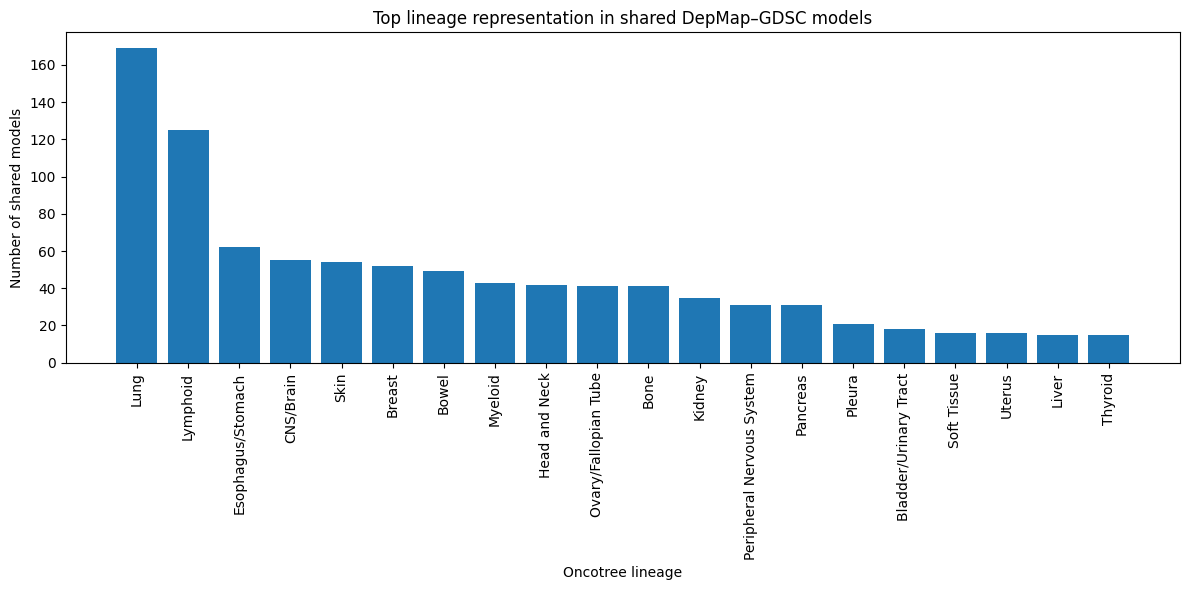

In [17]:
top_n = 20

plot_df = shared_lineage_counts.head(top_n)

plt.figure(figsize=(12, 6))

plt.bar(
    plot_df["lineage"],
    plot_df["n_models"]
)

plt.xticks(rotation=90)

plt.ylabel("Number of shared models")
plt.xlabel("Oncotree lineage")

plt.title("Top lineage representation in shared DepMap–GDSC models")

plt.tight_layout()

plt.show()

## Lineage retention after DepMap–GDSC overlap

This section evaluates how much lineage representation is retained after restricting the analysis to shared DepMap–GDSC models.

In [18]:
all_depmap_lineages = (
    depmap_models[DEPMAP_LINEAGE_COL]
    .value_counts(dropna=False)
    .rename_axis("lineage")
    .reset_index(name="total_depmap_models")
)

all_depmap_lineages.head()

,lineage,total_depmap_models
0,Lymphoid,260
1,Lung,260
2,Skin,149
3,CNS/Brain,125
4,Esophagus/Stomach,103


In [19]:
lineage_retention = (
    all_depmap_lineages
    .merge(
        shared_lineage_counts[
            ["lineage", "n_models"]
        ],
        on="lineage",
        how="left"
    )
    .fillna(0)
)

lineage_retention["n_models"] = (
    lineage_retention["n_models"]
    .astype(int)
)

lineage_retention["retention_pct"] = (
    lineage_retention["n_models"]
    / lineage_retention["total_depmap_models"]
    * 100
)

lineage_retention = lineage_retention.sort_values(
    "retention_pct",
    ascending=False
)

print(lineage_retention.head(20))

                      lineage  total_depmap_models  n_models  retention_pct
28               Vulva/Vagina                    5         5     100.000000
1                        Lung                  260       169      65.000000
4           Esophagus/Stomach                  103        62      60.194175
21                    Thyroid                   25        15      60.000000
19                     Pleura                   36        21      58.333333
22                     Cervix                   25        14      56.000000
11       Ovary/Fallopian Tube                   75        41      54.666667
6                      Breast                   96        52      54.166667
24                   Prostate                   15         8      53.333333
20                      Liver                   29        15      51.724138
14  Peripheral Nervous System                   60        31      51.666667
31              Adrenal Gland                    2         1      50.000000
33          

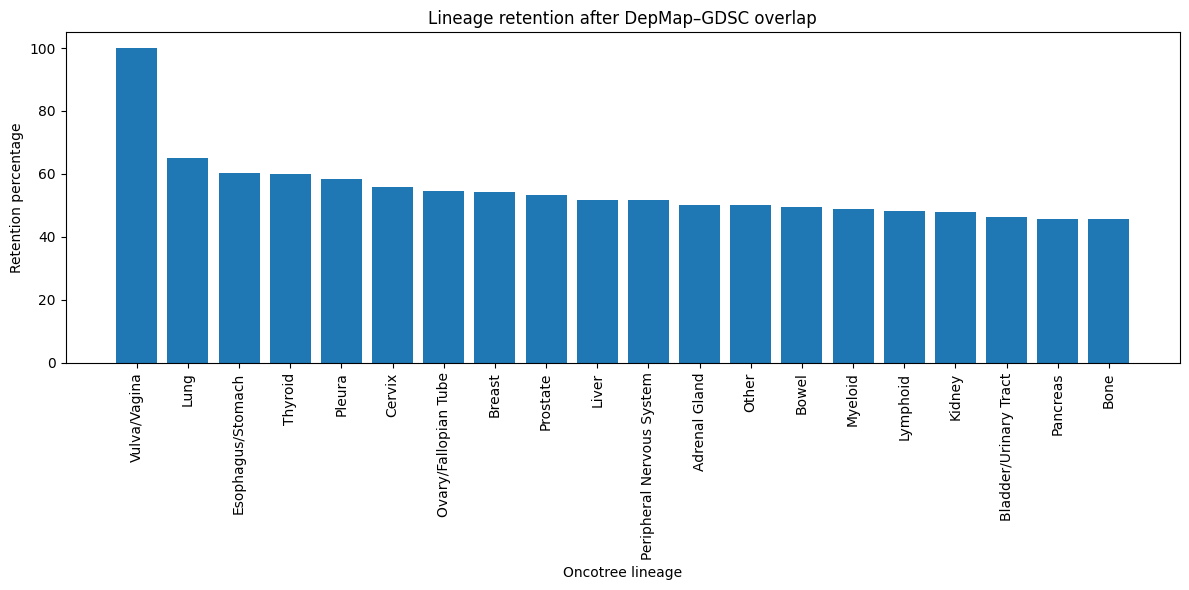

In [20]:
top_n = 20

plot_df = lineage_retention.head(top_n)

plt.figure(figsize=(12, 6))

plt.bar(
    plot_df["lineage"],
    plot_df["retention_pct"]
)

plt.xticks(rotation=90)

plt.ylabel("Retention percentage")
plt.xlabel("Oncotree lineage")

plt.title(
    "Lineage retention after DepMap–GDSC overlap"
)

plt.tight_layout()

plt.show()

## Pharmacogenomic response coverage

This section evaluates the structure and coverage of the GDSC drug-response space within the shared DepMap–GDSC cohort.

In [21]:
shared_gdsc_response = (
    gdsc_response[
        gdsc_response[GDSC_SANGER_COL]
        .astype(str)
        .isin(shared_sanger_ids)
    ]
    .copy()
)

shared_gdsc_response.shape

(241578, 16)

In [22]:
n_unique_drugs = (
    shared_gdsc_response[GDSC_DRUG_COL]
    .nunique()
)

n_unique_drugs

286

In [23]:
drug_counts = (
    shared_gdsc_response[GDSC_DRUG_COL]
    .value_counts()
    .rename_axis("drug")
    .reset_index(name="n_experiments")
)

drug_counts.head(20)

,drug,n_experiments
0,Ulixertinib,1695
1,Oxaliplatin,1681
2,Fulvestrant,1677
3,Selumetinib,1663
4,Dactinomycin,1656
5,Docetaxel,1634
6,GSK343,1631
7,Uprosertib,1631
8,Acetalax,1432
9,MG-132,967


In [24]:
drug_coverage_per_model = (
    shared_gdsc_response
    .groupby(GDSC_SANGER_COL)[GDSC_DRUG_COL]
    .nunique()
    .reset_index(name="n_unique_drugs")
)

drug_coverage_per_model.head()

,SANGER_MODEL_ID,n_unique_drugs
0,SIDM00003,232
1,SIDM00023,249
2,SIDM00040,180
3,SIDM00041,178
4,SIDM00042,270


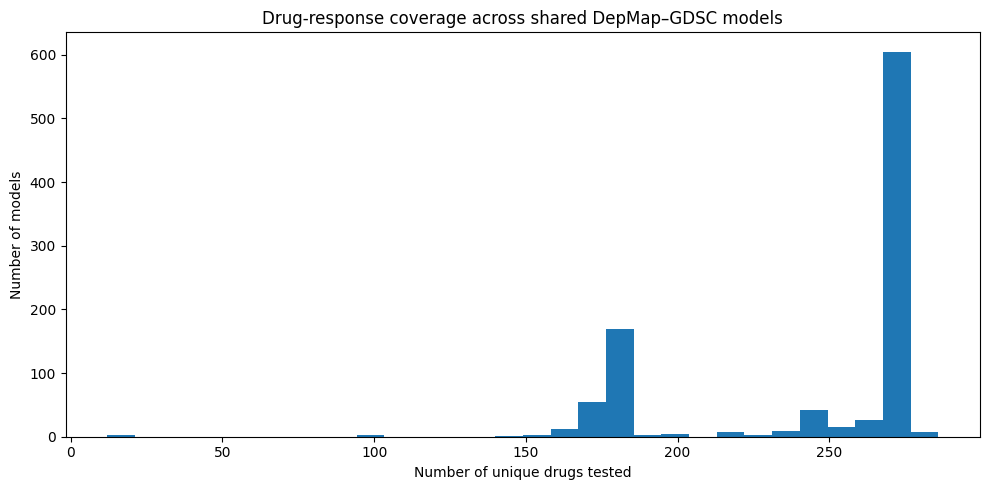

In [25]:
plt.figure(figsize=(10, 5))

plt.hist(
    drug_coverage_per_model["n_unique_drugs"],
    bins=30
)

plt.xlabel("Number of unique drugs tested")
plt.ylabel("Number of models")

plt.title(
    "Drug-response coverage across shared DepMap–GDSC models"
)

plt.tight_layout()

plt.show()

## Duplicate identifier checks

This section evaluates whether shared cross-dataset identifiers map uniquely to biological models before downstream overlap summaries are interpreted.

In [26]:
depmap_sanger_duplicates = (
    depmap_models
    .loc[depmap_models[DEPMAP_SANGER_COL].notna()]
    .groupby(DEPMAP_SANGER_COL)
    .size()
    .reset_index(name="n_depmap_models")
    .query("n_depmap_models > 1")
    .sort_values("n_depmap_models", ascending=False)
)

depmap_sanger_duplicates

,SangerModelID,n_depmap_models
87,SIDM00117,2


In [29]:
duplicated_sanger_ids = set(depmap_sanger_duplicates[DEPMAP_SANGER_COL])

depmap_models.loc[
    depmap_models[DEPMAP_SANGER_COL].isin(duplicated_sanger_ids),
    [
        DEP_MAP_ID_COL,
        DEPMAP_SANGER_COL,
        DEPMAP_CELL_LINE_COL,
        DEPMAP_LINEAGE_COL,
        "OncotreePrimaryDisease",
        "OncotreeSubtype",
        "CCLEName",
        "ModelType",
    ]
].sort_values(DEPMAP_SANGER_COL)

,ModelID,SangerModelID,CellLineName,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,CCLEName,ModelType
833,ACH-000837,SIDM00117,NCI-H322,Lung,Non-Small Cell Lung Cancer,Lung Adenocarcinoma,NCIH322_LUNG,Cell Line
1663,ACH-002172,SIDM00117,NCI-H322M,Lung,Non-Small Cell Lung Cancer,Lung Adenocarcinoma,NCIH322M_LUNG,Cell Line


---

## Drug-level coverage

This section evaluates the experimental coverage distribution across screened compounds within the shared DepMap–GDSC cohort.

Understanding drug-level coverage is important before defining downstream pharmacogenomic targets because many compounds may exhibit highly uneven representation across cell lines.

In [30]:
drug_model_coverage = (
    shared_gdsc_response
    .groupby(GDSC_DRUG_COL)[GDSC_SANGER_COL]
    .nunique()
    .reset_index(name="n_models_tested")
)

drug_model_coverage.head()

,DRUG_NAME,n_models_tested
0,123138,716
1,123829,716
2,150412,716
3,5-Fluorouracil,966
4,5-azacytidine,739


In [31]:
drug_model_coverage = drug_model_coverage.sort_values(
    "n_models_tested",
    ascending=False
)

drug_model_coverage.head(20)

,DRUG_NAME,n_models_tested
159,MG-132,967
205,Palbociclib,966
3,5-Fluorouracil,966
183,Nutlin-3a (-),966
163,MK-2206,966
238,Staurosporine,966
195,PD0325901,966
73,Camptothecin,966
87,Docetaxel,966
233,Selumetinib,965


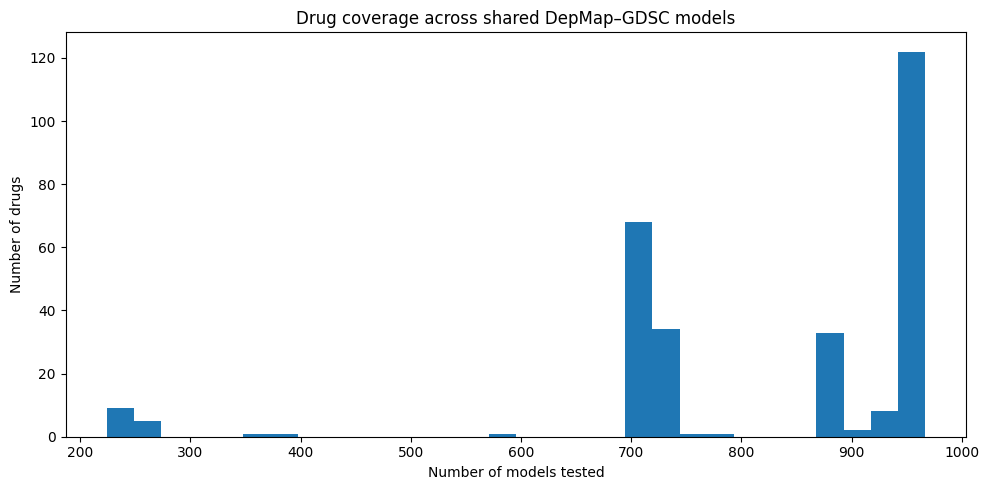

In [32]:
plt.figure(figsize=(10, 5))

plt.hist(
    drug_model_coverage["n_models_tested"],
    bins=30
)

plt.xlabel("Number of models tested")
plt.ylabel("Number of drugs")

plt.title(
    "Drug coverage across shared DepMap–GDSC models"
)

plt.tight_layout()

plt.show()

---

## Pharmacogenomic response distributions

This section evaluates the global distribution of the primary GDSC response metrics within the shared cohort.

In [33]:
response_missingness = pd.DataFrame([
    {
        "metric": GDSC_AUC_COL,
        "missing": shared_gdsc_response[GDSC_AUC_COL].isna().sum(),
        "missing_pct": (
            shared_gdsc_response[GDSC_AUC_COL]
            .isna()
            .mean()
            * 100
        ),
    },
    {
        "metric": GDSC_LN_IC50_COL,
        "missing": shared_gdsc_response[GDSC_LN_IC50_COL].isna().sum(),
        "missing_pct": (
            shared_gdsc_response[GDSC_LN_IC50_COL]
            .isna()
            .mean()
            * 100
        ),
    },
])

response_missingness

,metric,missing,missing_pct
0,AUC,0,0.0
1,LN_IC50,0,0.0


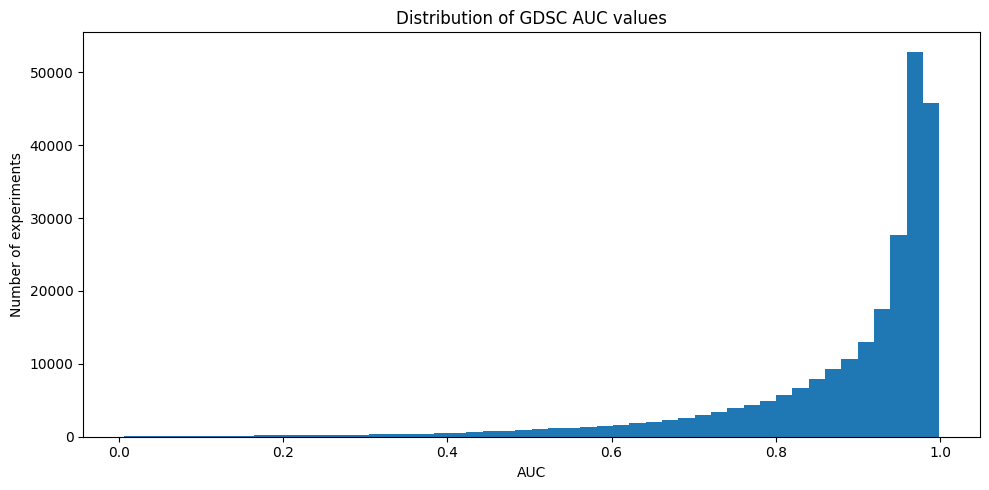

In [34]:
plt.figure(figsize=(10, 5))

plt.hist(
    shared_gdsc_response[GDSC_AUC_COL].dropna(),
    bins=50
)

plt.xlabel("AUC")
plt.ylabel("Number of experiments")

plt.title("Distribution of GDSC AUC values")

plt.tight_layout()

plt.show()

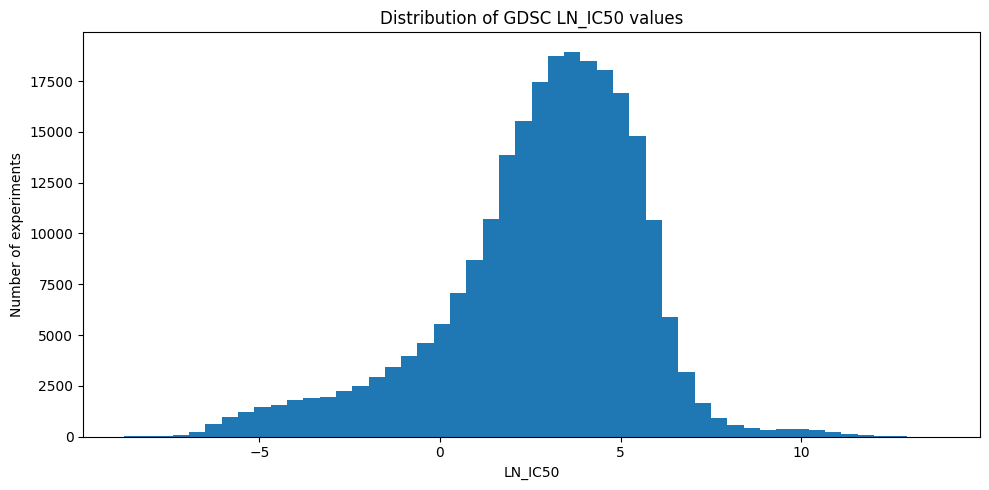

In [35]:
plt.figure(figsize=(10, 5))

plt.hist(
    shared_gdsc_response[GDSC_LN_IC50_COL].dropna(),
    bins=50
)

plt.xlabel("LN_IC50")
plt.ylabel("Number of experiments")

plt.title("Distribution of GDSC LN_IC50 values")

plt.tight_layout()

plt.show()

In [36]:
# =============================================================================
# Export shared DepMap-GDSC model universe
# =============================================================================

INTERIM_DATA_DIR = Paths.interim
INTERIM_DATA_DIR.mkdir(parents=True, exist_ok=True)

shared_depmap_models_export_path = (
    INTERIM_DATA_DIR / "20_shared_depmap_gdsc_models.csv"
)

shared_depmap_models.to_csv(shared_depmap_models_export_path, index=False)

print(f"Exported: {shared_depmap_models_export_path}")
print(f"Shape: {shared_depmap_models.shape}")

Exported: c:\Users\paula\OneDrive\Documentos\Proyectos\pancancer-epigenetics\data\interim\20_shared_depmap_gdsc_models.csv
Shape: (968, 8)
